In [ ]:
#import libraries
import pydicom
import numpy as np
import os
#define a path to a single DICOM slice
#(you need to change this path to the correct one!)
path_to_one_dcm_slice='C:/User/Data/patient0001/DICOM/12345.dcm'
#read this slice
ds=pydicom.dcmread(path_to_one_dcm_slice)
#now, we can call any DICOM attribute (e.g. study date) by its name...
print('Study date:',ds.StudyDate)
#... or by its tag
print('Study date:',ds[0x0008, 0x0020].value)
#alternatively, we can print the whole header at once
print(ds)

#define then a function for reconstructing the original 3D or 4D image
def read_dcm_image(path_to_dcm_folder):
    #the input is the path to the folder containing all the DICOM slices
    #first, create a list of the names of all the files in this folders
    filenames=os.listdir(path_to_dcm_folder)
    #then create a list of filenames which are DICOM (i.e. have .dcm ending)
    dcm_filenames=[]
    for i in range(len(filenames)):
        if filenames[i][-4:]=='.dcm':
            dcm_filenames.append(filenames[i])
    #open the first DICOM file
    file_path='{}/{}'.format(path_to_dcm_folder,dcm_filenames[0])
    ds=pydicom.dcmread(file_path)
    #check along which axis the 3D image have been separated into 2D 
    # DICOM slices 
    #(this is the index that has a value close to 0 as the direction
    # cosine for both the rows iop[0:3] and the columns iop[3:6])
    iop=ds.ImageOrientationPatient
    location_index=np.argmin(np.array(iop[0:3])+np.array(iop[3:6]))
    #initialise lists for slices, their locations, and times
    slice_list=[]
    locations=[]
    times=[]
    #fill the lists by going through all the DICOM slices
    for i in range(len(dcm_filenames)):
        file='{}/{}'.format(path_to_dcm_folder,dcm_filenames[i])
        ds=pydicom.dcmread(file)
        locations.append(ds.ImagePositionPatient[location_index])
        times.append(ds.AcquisitionTime)
        if 'RescaleSlope' in ds and 'RescaleIntercept' in ds:
            slice_list.append(ds.pixel_array*ds.RescaleSlope+ ds.RescaleIntercept)
        else:
            slice_list.append(ds.pixel_array)
    #create new lists of the unique values of the slice locations and
    # acquisation times
    unique_locations=np.sort(np.unique(np.array(locations)))
    unique_times=np.sort(np.unique(np.array(times)))
    #define the voxel size
    voxel_size=np.array([ds.PixelSpacing[0],ds.PixelSpacing[1], unique_locations[1]-unique_locations[0]])
    #if all the locations are unique, assume that the image is 3D
    if len(unique_locations)==len(locations):
        #order the slices based on the locations
        merged=dict(zip(locations,slice_list))
        ordered_slice_list=[merged[loc] for loc in sorted(locations)]
        #create a 3D array and order the axes correctly
        img_3d=np.moveaxis(np.array(ordered_slice_list),0,2)
        img_3d=np.moveaxis(img_3d,0,1)
        return(img_3d,voxel_size)
    else:
        #otherwise, assume that the image is 4D
        img_4d=[]
        #find the 3D time-frames for all unique time values
        for i in range(len(unique_times)):
            locations_1=list(np.array(locations)[np.array(times)== unique_times[i]])
            slice_list_1=list(np.array(slice_list)[np.array(times)== unique_times[i]])
            merged=dict(zip(locations_1,slice_list_1))
            ordered_slice_list=[merged[loc] for loc in sorted(locations_1)]
            img_3d=np.moveaxis(np.array(ordered_slice_list),0,2)
            img_3d=np.moveaxis(img_3d,0,1)
            img_4d.append(img_3d)
        img_4d=np.moveaxis(np.array(img_4d),0,3)
        return(img_4d,voxel_size)

#define the path to the DICOM folder
#(you need to change this path to the correct one!)
path_to_dcm_folder='C:/User/Data/patient0001/DICOM'
#run the function to obtain the 3D or 4D image
img,voxel_size=read_dcm_image(path_to_dcm_folder)
#check its dimension and size
print('Voxel dimensions:',img.shape)
print('Voxel size:',voxel_size)

In [ ]:
import nibabel as nib
import numpy as np
#define a path to the nifti file
#(you need to change this path to the correct one!)
path_to_nifti_file='C:/User/Data/patient0001/nifti/pet.nifti.img'
#load the nifti file
nifti_file=nib.load(path_to_nifti_file)
#access the actual image
img=nifti_file.get_fdata()
#print the nifti file header
print(nifti_file.header)
#use the information of the affine point coordinates to define the voxel size
voxel_size=np.diagonal(abs(nifti_file.affine))[0:3]
#print both the dimensions of the image and its voxel size
print('Voxel dimensions:',img.shape)
print('Voxel size:',voxel_size)

Image dimensions: (100, 100, 35)


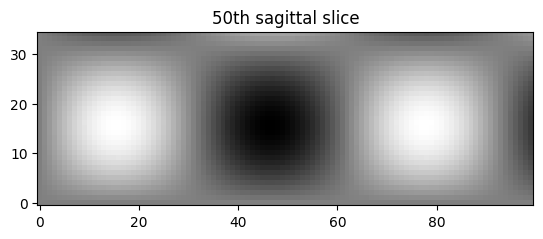

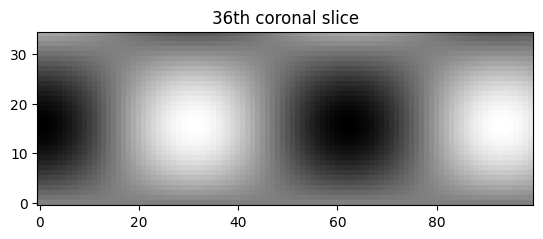

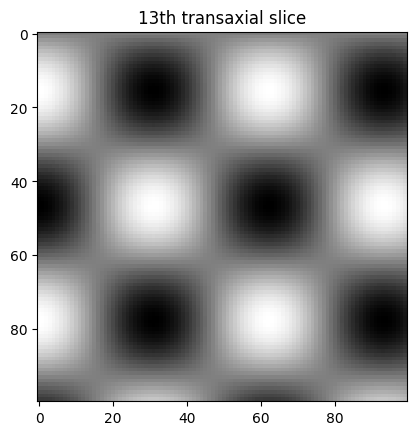

Image dimensions after moving the axis: (100, 35, 100)


In [1]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
#let us initialise an array to substitute a PET image in this example
#define first a vector x containing 100 evenly-spaced values between 0
# and 10
x=np.linspace(0,10,100)
#then by using the vector x, create a 100*100*35 matrix with values
# obtained from x with sine and cosine functions (used in place of
# a 3D PET image)
img_3d=10*(np.sin(x[0:35])*np.sin(x[:,np.newaxis])*np.cos(x[:,np.newaxis,
    np.newaxis])+1)
#print the voxel dimensions
print('Image dimensions:',img_3d.shape)
#plot example slices assuming that the LPS is used
plt.imshow(np.transpose(img_3d[50,:,:]),origin='lower',cmap='gray')
plt.title('50th sagittal slice')
plt.show()
plt.imshow(np.transpose(img_3d[:,36,:]),origin='lower',cmap='gray')
plt.title('36th coronal slice')
plt.show()
plt.imshow(np.transpose(img_3d[:,:,13]),origin='upper',cmap='gray')
plt.title('13th transaxial slice')
plt.show()
#if the voxel dimensions are incorrect, they can be adjusted
#we can e.g. move the location of the first axis to be the third one...
img_3d_new=np.moveaxis(img_3d,source=0,destination=2)
print('Image dimensions after moving the axis:',img_3d_new.shape)
#... or we can flip the image around the first axis
img_3d_new_2=np.flip(img_3d,axis=0)

(100, 100, 35)
Original image shape: (100, 35)


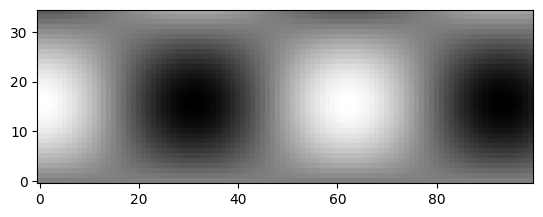

Image shape after scaling: (100, 61)


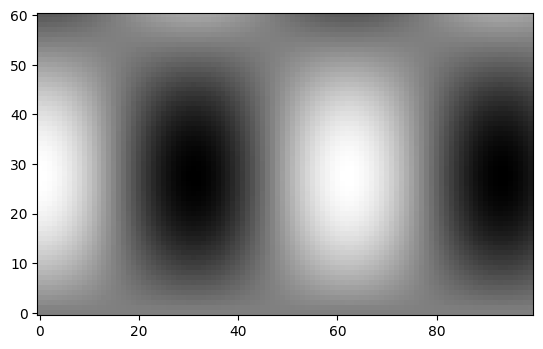

In [2]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import cv2
#initialise an array to substitute a PET image
x=np.linspace(0,10,100)
img_3d=10*(np.sin(x[0:35])*np.sin(x[:,np.newaxis])*np.cos(x[:,np.newaxis,
    np.newaxis])+1)
print(img_3d.shape)
#now, choose e.g. the 31st coronal plane of the image
img_unscaled=img_3d[:,30,:]
print('Original image shape:',img_unscaled.shape)
#plot this image selection without scaling its height
plt.imshow(np.transpose(img_unscaled),origin='lower',cmap='gray')
plt.show()
#initialise some voxel size (here, 1.9*1.9*3.3 mm^3)
voxel_size=np.array([1.9,1.9,3.30])
#then, to produce a realistic image with the aforementioned voxelSize
# selection, scale its height
img_width=img_unscaled.shape[0]
img_height_original=img_unscaled.shape[1]
img_height=round(voxel_size[2]/voxel_size[0]*img_height_original)
img_scaled=cv2.resize(img_unscaled,(img_height,img_width))
print('Image shape after scaling:',img_scaled.shape)
#plot the new image
plt.imshow(np.transpose(img_scaled),origin='lower',cmap='gray')
plt.show()

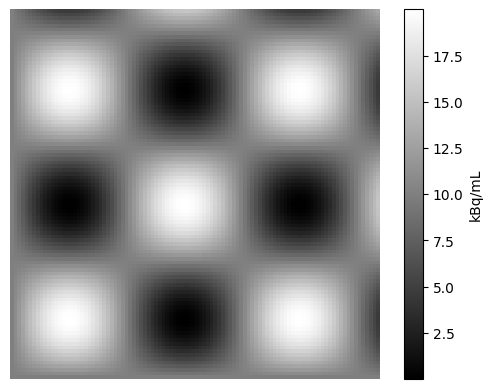

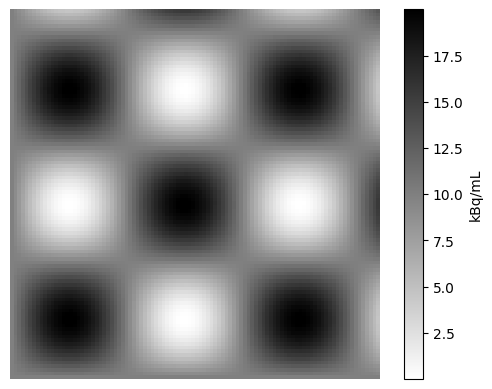

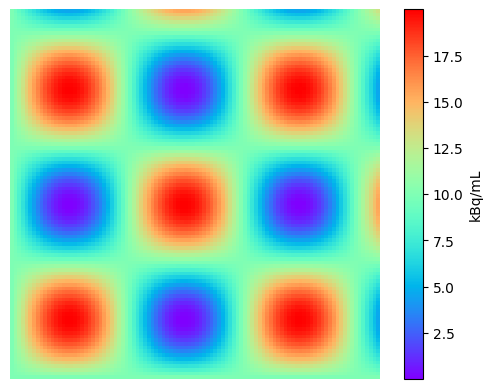

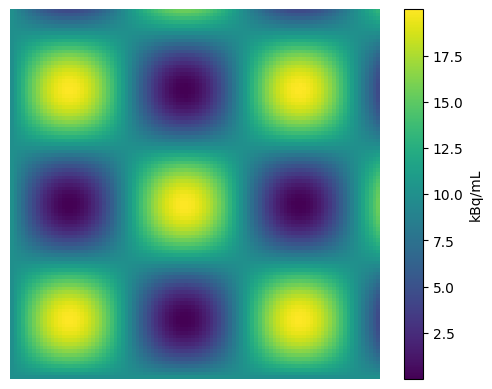

In [3]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
#initialise an array to substitute a 2D selection from a PET image
x=np.linspace(0,10,100)
img_2d=10*(np.sin(x)*np.sin(x[:,np.newaxis]))+10
#plot it with a typical greyscale colour map (with a colourbar but without
# the axes)
plt.imshow(np.transpose(img_2d),origin='lower',cmap='gray')
#let us assume that the concentration is in kBq/mL and use this unit in
# the colourbar
plt.colorbar(label='kBq/mL')
plt.axis('off')
plt.show()
#plot it with an inverted greyscale colour map
plt.imshow(np.transpose(img_2d),origin='lower',cmap='gray_r')
plt.colorbar(label='kBq/mL')
plt.axis('off')
plt.show()
#plot it with a rainbow colour map
plt.imshow(np.transpose(img_2d),origin='lower',cmap='rainbow')
plt.colorbar(label='kBq/mL')
plt.axis('off')
plt.show()
#plot it with a viridis colour map
plt.imshow(np.transpose(img_2d),origin='lower',cmap='viridis')
plt.colorbar(label='kBq/mL')
plt.axis('off')
plt.show()

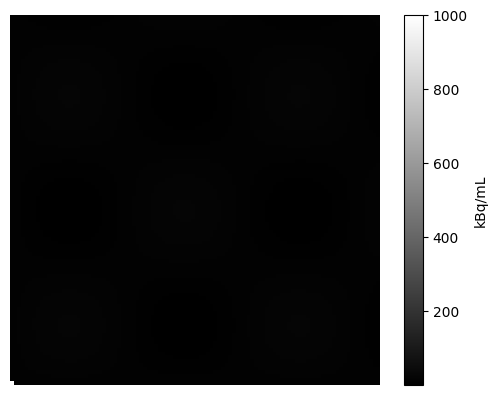

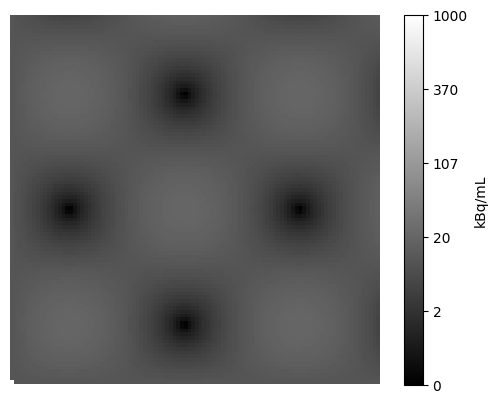

In [4]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
#initialise an array to substitute a 2D selection from a PET image
x=np.linspace(0,10,100)
img_2d=10*(np.sin(x)*np.sin(x[:,np.newaxis]))+10
#add an outlier value to the image img_2d
img_2d[0,0]=1000
#plot the result
plt.imshow(np.transpose(img_2d),cmap='gray',origin='lower')
plt.colorbar(label='kBq/mL')
plt.axis('off')
plt.show()
#create a new version of the image with an exponential function
img_adjusted=img_2d**0.2
#plot the adjusted image
plt.imshow(np.transpose(img_adjusted),cmap='gray',origin='lower')
cb1=plt.colorbar(label='kBq/mL')
#create ticks and labels for the colourbar in a loop by going through
# five evenly-spaced values between the minimum and the maximum
# of the adjusted image to be used as tick locations
# and checking what the original values at these
# ticks were by using the inverse function x^5 of the function x^0.2
myTicks=[]
myLabels=[]
for i in range(6):
    t=np.min(img_adjusted)+i*(np.max(img_adjusted)-np.min(img_adjusted))/5
    myTicks.append(t)
    myLabels.append(str(round(t**5)))
cb1.set_ticks(ticks=myTicks,labels=myLabels)
plt.axis('off')
plt.show()

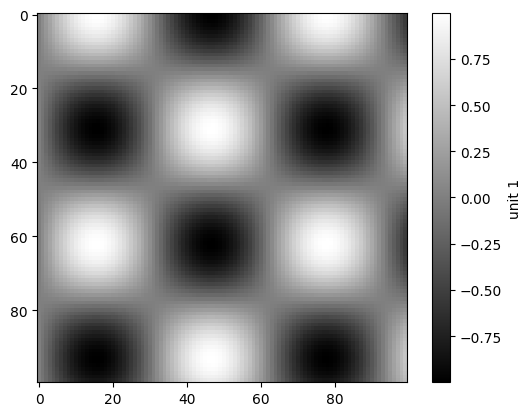

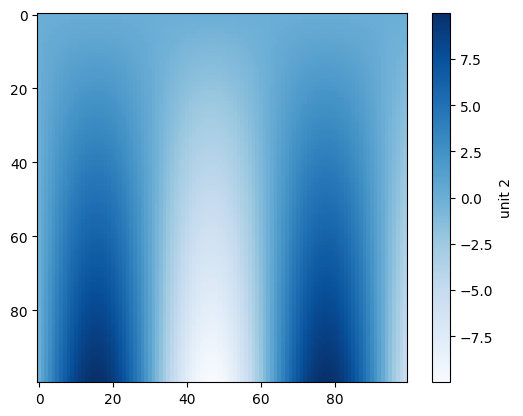

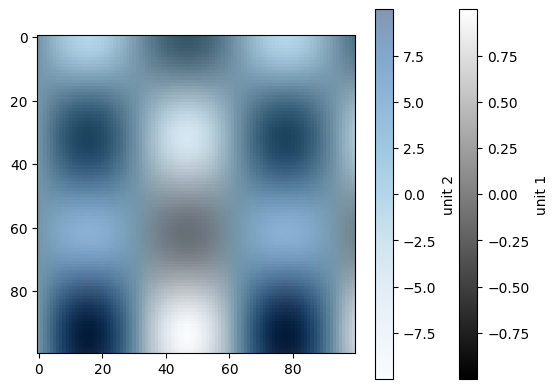

In [5]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
#initialise two images
x=np.linspace(0,10,100)
img_1=np.sin(x)*np.cos(x[:,np.newaxis])
img_2=np.sin(x)*x[:,np.newaxis]
#plot the images separately with greyscale and blue colourmaps
plt.imshow(img_1,cmap='gray')
plt.colorbar(label='unit 1')
plt.show()
plt.imshow(img_2,cmap='Blues')
plt.colorbar(label='unit 2')
plt.show()
#plot the images on top of each other so that the second image is
# semi-transparent
plt.imshow(img_1,cmap='gray')
plt.colorbar(label='unit 1')
#the smaller the value of alpha is, the more transparent image is
#alpha=0 -> a fully transparent image
#alpha=1 -> a fully opaque image
plt.imshow(img_2,alpha=0.5,cmap='Blues')
plt.colorbar(label='unit 2')
plt.show()

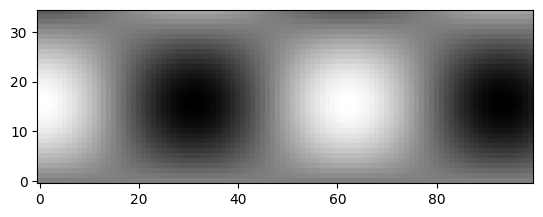

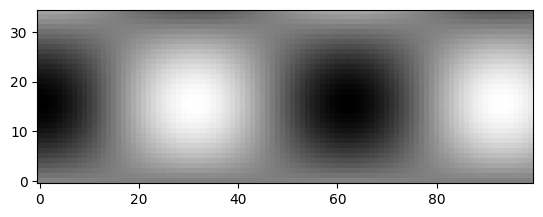

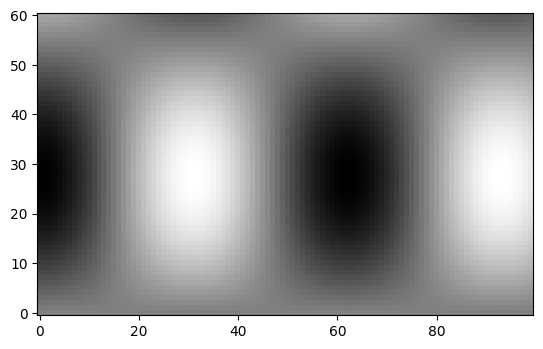

In [6]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import cv2
#let us initialise an array to substitute a PET
x=np.linspace(0,10,100)
img_3d=10*(np.sin(x[0:35])*np.sin(x[:,np.newaxis])*np.cos(x[:,np.newaxis,
    np.newaxis])+1)
#the element-wise mean all the coronal slices of a 3D image is taken as
# follows
img_mean_coronal=np.mean(img_3d,axis=1)
plt.imshow(np.transpose(img_mean_coronal),origin='lower',
    cmap='gray')
plt.show()
#here, the "axis=1" means that the mean is computed over the second axis 
# (i.e. over coronal slices in LPS)
#by choosing "axis=0" or "axis=2", we could compute the mean over 
# sagittal or transaxial slices
#(or, in case of dynamic 4D images, we could compute the mean over time-points by using "axis=3")
#if we want the mean between just some of the coronal slices, we can 
# choose e.g.:
img_mean_coronal_30_40=np.mean(img_3d[:,30:41,:],axis=1)
plt.imshow(np.transpose(img_mean_coronal_30_40),origin='lower',
    cmap='gray')
plt.show()
#scale this image with the example voxel shape
voxel_size=np.array([1.9,1.9,3.30])
img_width=img_mean_coronal_30_40.shape[0]
img_height_original=img_mean_coronal_30_40.shape[1]
img_height=round(voxel_size[2]/voxel_size[0]*img_height_original)
img_mean_coronal_30_40=cv2.resize(img_mean_coronal_30_40,
    (img_height,img_width))
#plot the new image
plt.imshow(np.transpose(img_mean_coronal_30_40),origin='lower',
    cmap='gray')
plt.show()

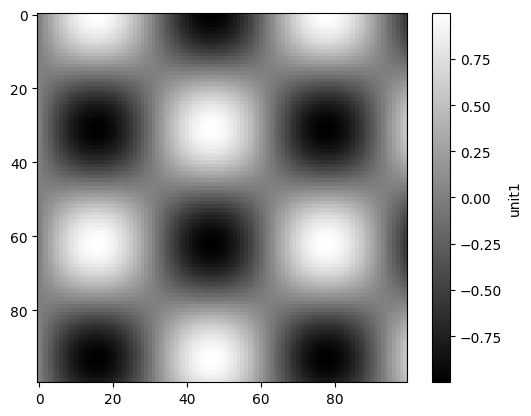

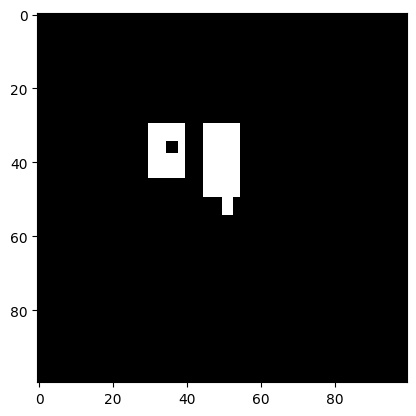

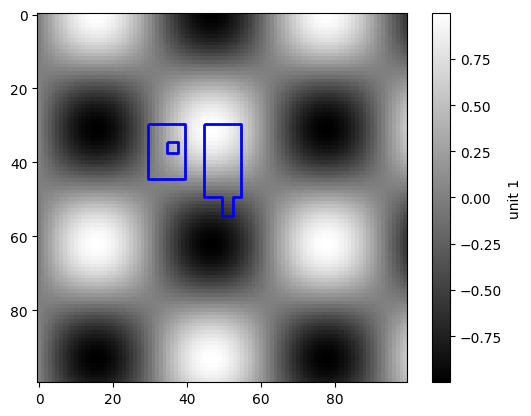

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

def get_all_edges(bool_img):
    #Get a list of all edges (where the value changes from True to False)
    # in the 2D boolean image.
    #The returned array edges has he dimension (n, 2, 2).
    #Edge i connects the pixels edges[i, 0, :] and edges[i, 1, :].
    #Note that the indices of a pixel also denote the coordinates of its
    # lower left corner.
    edges = []
    ii, jj = np.nonzero(bool_img)
    for i, j in zip(ii, jj):
        # North
        if j == bool_img.shape[1]-1 or not bool_img[i, j+1]:
            edges.append(np.array([[i, j+1],
                                   [i+1, j+1]]))
        # East
        if i == bool_img.shape[0]-1 or not bool_img[i+1, j]:
            edges.append(np.array([[i+1, j],
                                   [i+1, j+1]]))
        # South
        if j == 0 or not bool_img[i, j-1]:
            edges.append(np.array([[i, j],
                                   [i+1, j]]))
        # West
        if i == 0 or not bool_img[i-1, j]:
            edges.append(np.array([[i, j],
                                   [i, j+1]]))
    if not edges:
        return np.zeros((0, 2, 2))
    else:
        return np.array(edges)
    
def close_loop_edges(edges):
    #Combine the edges defined by 'get_all_edges' to closed loops around
    # objects.
    #If there are multiple disconnected objects a list of closed loops is
    # returned.
    #Note that it's expected that all the edges are part of exactly one
    # loop (but not necessarily the same one).
    loop_list = []
    while edges.size != 0:
        loop = [edges[0, 0], edges[0, 1]]  # Start with first edge
        edges = np.delete(edges, 0, axis=0)
        while edges.size != 0:
            # Get next edge (=edge with common node)
            ij = np.nonzero((edges == loop[-1]).all(axis=2))
            if ij[0].size > 0:
                i = ij[0][0]
                j = ij[1][0]
            else:
                loop.append(loop[0])
                # Uncomment to to make the start of the loop invisible when
                # plotting
                # loop.append(loop[1])
                break
            loop.append(edges[i, (j + 1) % 2, :])
            edges = np.delete(edges, i, axis=0)
        loop_list.append(np.array(loop))
    return loop_list

def plot_outlines(bool_img, ax=None, **kwargs):
    if ax is None:
        ax = plt.gca()
    edges = get_all_edges(bool_img=bool_img)
    edges = edges - 0.5  # convert indices to coordinates; 
    # adjust according to image extent if necessary
    outlines = close_loop_edges(edges=edges)
    cl = LineCollection(outlines, **kwargs)
    ax.add_collection(cl)

#initialise an image to substitute a PET image
x=np.linspace(0,10,100)
img_1=np.sin(x)*np.cos(x[:,np.newaxis])
#initialise a matrix to substitute the binary mask
mask=np.zeros(img_1.shape)
mask[30:50,45:55]=1
mask[45:55,50:53]=1
mask[30:45,30:40]=1
mask[35:38,35:38]=0
#plot both separately
plt.imshow(img_1,cmap='gray')
plt.colorbar(label='unit1')
plt.show()
plt.imshow(mask,cmap='gray')
plt.show()
#plot outlines of the binary mask on the first image
plt.imshow(img_1,cmap='gray')
plt.colorbar(label='unit 1')
plot_outlines(mask.T, lw=2, color='blue')
plt.show()